# Dataset Description

In this notebook, we perform Univariate Exploratory Data Analysis on a student performance dataset.

The dataset contains information about students including:
- Student ID
- Name
- Class
- Gender
- Age
- Hours Studied
- Marks

The goal of this analysis is to understand the distribution of variables, detect outliers, and analyze categorical data using Seaborn, Pandas, and Matplotlib.

___

## Step 1: Load Dataset and Produce Histograms for Numeric Variables

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("homework.csv")

numeric_columns = df.select_dtypes(include="number").columns
numeric_columns

Index(['ID', 'Mark', 'Age', 'Hours_Studied'], dtype='str')

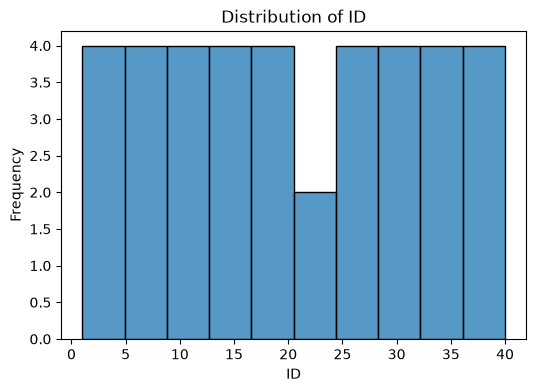

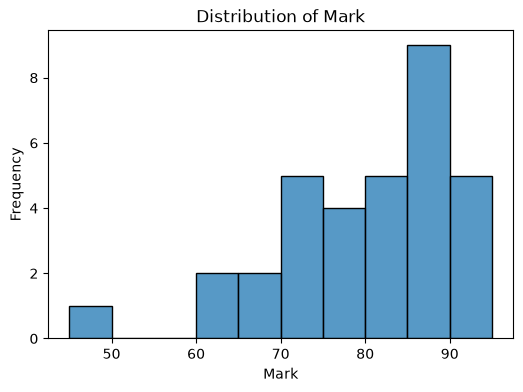

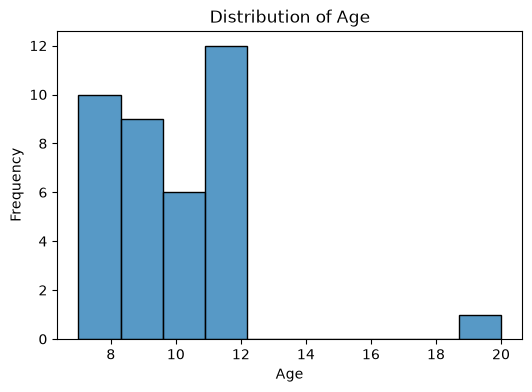

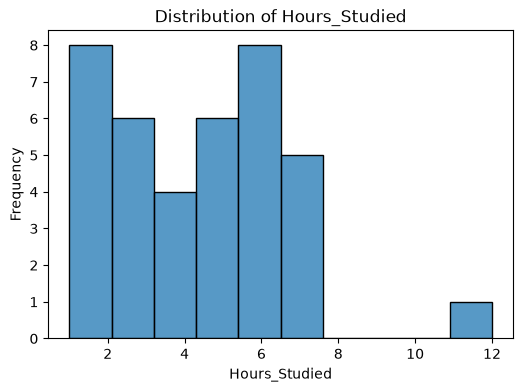

In [54]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, bins=10)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

#### Histogram Interpretation

The histograms show the distribution of numerical variables:

- **Mark:**  
  Shows how students' marks are distributed. Most students have marks concentrated in the middle and higher ranges.

- **Age:**  
  The ages are concentrated between 7 and 11 years, showing a limited age range.

- **Hours_Studied:**  
  Shows the number of study hours. Most students study between 2 and 6 hours.

- **ID:**  
  The ID column increases sequentially and does not represent meaningful statistical information, so it is not useful for modeling.
  

___

## Step 2: Box Plot and Outlier Detection

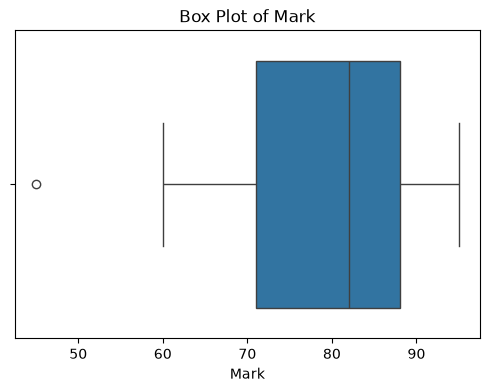

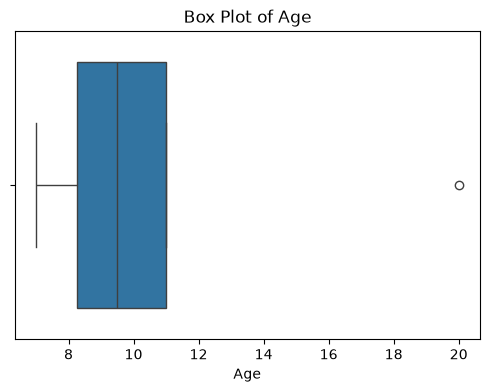

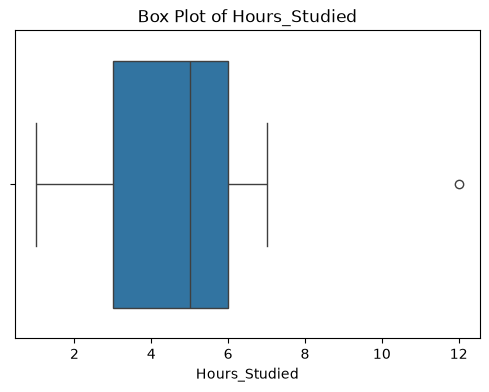

In [55]:
key_numeric = ["Mark", "Age", "Hours_Studied"]

for col in key_numeric:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x=col)
    plt.title(f"Box Plot of {col}")
    plt.show()

#### Box Plot Interpretation

The box plots reveal the following observations:

- **Mark**:
Most students have marks between approximately 60 and 95.
The value 45 appears as a possible outlier because it is significantly lower than the other marks.

- **Age**:
Most students are between 7 and 11 years old.
The age value 20 appears as an outlier because it is much higher than the normal age range in the dataset.

- **Hours_Studied**:
Most students study between 1 and 7 hours.
The value 12 hours appears as an outlier because it is higher than the general distribution of study hours.

These detected outliers will be further investigated using the IQR method in the next step.


___

## Step 3: Apply IQR Method for Outlier Detection

In [56]:
def detect_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    l = Q1 - 1.5 * IQR
    u = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < l) |
        (data[column] > u)
    ]

    return outliers



for col in key_numeric:
    print(f"Outliers in {col}")
    print(detect_outliers(df, col))
    print("-------------------")

Outliers in Mark
    ID  Name   Class  Mark Gender  Age  Hours_Studied
37  40  Jack  Fourth  45.0   Male   20              7
-------------------
Outliers in Age
    ID  Name   Class  Mark Gender  Age  Hours_Studied
37  40  Jack  Fourth  45.0   Male   20              7
-------------------
Outliers in Hours_Studied
    ID  Name   Class  Mark  Gender  Age  Hours_Studied
21  24  Anna  Second  88.0  Female    8             12
-------------------


#### IQR Method Interpretation

After applying the IQR method:

- The Age column contains an outlier (Age = 20), because it is significantly higher than the normal age range in the dataset.
- The Hours_Studied column contains an outlier (12 hours), because most students study between 1 and 7 hours.
- The Mark column contains a possible low outlier (45), which represents an unusually low score.

These values should be investigated before modeling.

Since these values may represent real observations and not data entry mistakes, they should not be removed automatically. A suitable approach is to verify the source of the data first. If they are valid, they can be kept or handled using robust methods.


___
## Step 4: Count Plot for Categorical Variables

In [57]:
categorical_columns = ["Class", "Gender"]
categorical_columns

['Class', 'Gender']

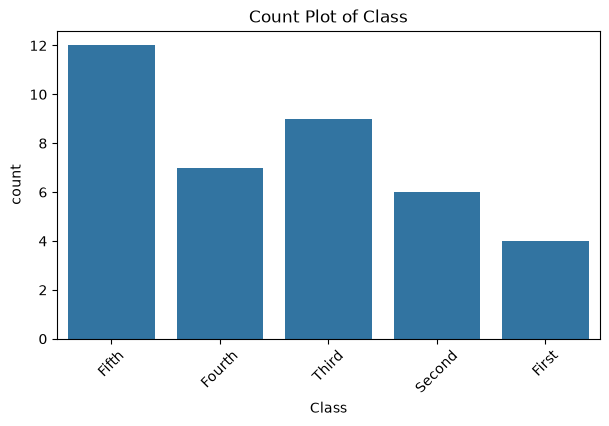

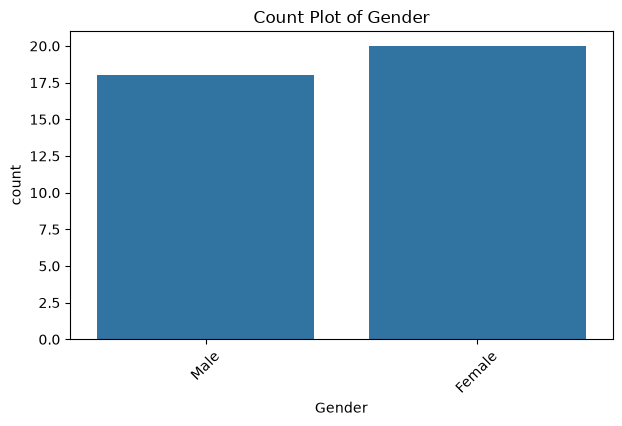

In [58]:
for col in categorical_columns:
    plt.figure(figsize=(7,4))
    sns.countplot(data=df, x=col)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

#### Count Plot Interpretation

The count plots reveal:

- **Gender**:
The number of male and female students is relatively balanced.
There is no significant class imbalance.

- **Class**:
Students are distributed across different classes.
Some classes contain more students than others, but the imbalance is not severe.

Balanced categorical variables are useful because models can learn patterns without being biased toward one category.
**The Name column was excluded from visualization because it represents student identity rather than a meaningful categorical feature.** 

___

## Step 5: Overall EDA Findings

After performing univariate analysis:

#### Numerical Variables

- Marks show the performance distribution among students.
- Age values are consistent and within a narrow range.
- Hours studied provides information about students' study habits.
- No major numerical outliers were detected.

#### Categorical Variables

- Gender distribution is balanced.
- Classes have different numbers of students, but there is no extreme imbalance.

#### Data Quality

- Missing values exist in the Mark column.
- Missing marks should be handled before machine learning modeling.
- Possible approaches include:
    - Removing rows with missing values if the dataset is large.
    - Filling missing values using mean or median values.

EDA helped us understand the dataset structure and identify potential issues before applying machine learning algorithms.